# Введение

# imports

In [1]:
import itertools
import json

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

# Данные/EDA

In [2]:
raw_features = pd.read_csv("train_features.csv")
raw_features.head()

,match_id_hash,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,r1_gold,r1_lh,r1_xp,r1_health,r1_max_health,r1_max_mana,r1_level,r1_x,r1_y,r1_stuns,r1_creeps_stacked,r1_camps_stacked,r1_rune_pickups,r1_firstblood_claimed,r1_teamfight_participation,r1_towers_killed,r1_roshans_killed,r1_obs_placed,r1_sen_placed,r2_hero_id,r2_kills,r2_deaths,r2_assists,r2_denies,r2_gold,r2_lh,r2_xp,r2_health,r2_max_health,r2_max_mana,r2_level,r2_x,r2_y,r2_stuns,r2_creeps_stacked,r2_camps_stacked,r2_rune_pickups,r2_firstblood_claimed,r2_teamfight_participation,r2_towers_killed,r2_roshans_killed,r2_obs_placed,r2_sen_placed,r3_hero_id,r3_kills,r3_deaths,r3_assists,r3_denies,r3_gold,r3_lh,r3_xp,r3_health,r3_max_health,r3_max_mana,r3_level,r3_x,r3_y,r3_stuns,r3_creeps_stacked,r3_camps_stacked,r3_rune_pickups,r3_firstblood_claimed,r3_teamfight_participation,r3_towers_killed,r3_roshans_killed,r3_obs_placed,r3_sen_placed,r4_hero_id,r4_kills,r4_deaths,r4_assists,r4_denies,r4_gold,r4_lh,r4_xp,r4_health,r4_max_health,r4_max_mana,r4_level,r4_x,r4_y,r4_stuns,r4_creeps_stacked,r4_camps_stacked,r4_rune_pickups,r4_firstblood_claimed,r4_teamfight_participation,r4_towers_killed,r4_roshans_killed,r4_obs_placed,r4_sen_placed,r5_hero_id,r5_kills,r5_deaths,r5_assists,r5_denies,r5_gold,r5_lh,r5_xp,r5_health,r5_max_health,r5_max_mana,r5_level,r5_x,r5_y,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed,d1_hero_id,d1_kills,d1_deaths,d1_assists,d1_denies,d1_gold,d1_lh,d1_xp,d1_health,d1_max_health,d1_max_mana,d1_level,d1_x,d1_y,d1_stuns,d1_creeps_stacked,d1_camps_stacked,d1_rune_pickups,d1_firstblood_claimed,d1_teamfight_participation,d1_towers_killed,d1_roshans_killed,d1_obs_placed,d1_sen_placed,d2_hero_id,d2_kills,d2_deaths,d2_assists,d2_denies,d2_gold,d2_lh,d2_xp,d2_health,d2_max_health,d2_max_mana,d2_level,d2_x,d2_y,d2_stuns,d2_creeps_stacked,d2_camps_stacked,d2_rune_pickups,d2_firstblood_claimed,d2_teamfight_participation,d2_towers_killed,d2_roshans_killed,d2_obs_placed,d2_sen_placed,d3_hero_id,d3_kills,d3_deaths,d3_assists,d3_denies,d3_gold,d3_lh,d3_xp,d3_health,d3_max_health,d3_max_mana,d3_level,d3_x,d3_y,d3_stuns,d3_creeps_stacked,d3_camps_stacked,d3_rune_pickups,d3_firstblood_claimed,d3_teamfight_participation,d3_towers_killed,d3_roshans_killed,d3_obs_placed,d3_sen_placed,d4_hero_id,d4_kills,d4_deaths,d4_assists,d4_denies,d4_gold,d4_lh,d4_xp,d4_health,d4_max_health,d4_max_mana,d4_level,d4_x,d4_y,d4_stuns,d4_creeps_stacked,d4_camps_stacked,d4_rune_pickups,d4_firstblood_claimed,d4_teamfight_participation,d4_towers_killed,d4_roshans_killed,d4_obs_placed,d4_sen_placed,d5_hero_id,d5_kills,d5_deaths,d5_assists,d5_denies,d5_gold,d5_lh,d5_xp,d5_health,d5_max_health,d5_max_mana,d5_level,d5_x,d5_y,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed
0,a400b8f29dece5f4d266f49f1ae2e98a,155,22,7,1,11,11,0,0,0,0,543,7,533,358,600,350.93784,2,116,122,0.000000,0,0,1,0,0.000000,0,0,0,0,78,0,0,0,3,399,4,478,636,720,254.93774,2,124,126,0.000000,0,0,0,0,0.000000,0,0,0,0,14,0,1,0,0,304,0,130,700,700,242.93773,1,70,156,0.000000,0,0,1,0,0.000000,0,0,0,0,59,0,0,0,1,389,4,506,399,700,326.93780,2,170,86,0.000000,0,0,0,0,0.000000,0,0,0,0,77,0,0,0,0,402,10,344,422,800,314.93780,2,120,100,0.000000,0,0,0,0,0.000000,0,0,0,0,12,0,0,1,13,982,12,780,650,720,386.93787,3,82,170,0.000000,0,0,1,0,1.00,0,0,0,0,21,0,0,0,6,788,9,706,640,640,422.93790,3,174,90,0.000000,0,0,2,0,0.00,0,0,0,0,60,0,0,0,1,531,0,307,720,720,242.93773,2,180,84,0.299948,0,0,2,0,0.00,0,0,0,0,84,1,0,0,0,796,0,421,760,760,326.93780,2,90,150,0.000000,0,0,2,1,1.0,0,0,1,0,34,0,0,0,0,851,11,870,593,680,566.93805,3,128,128,0.000000,0,0,0,0,0.00,0,0,0,0
1,b9c57c450ce74a2af79c9ce96fac144d,658,4,0,3,10,15,7,2,0,7,5257,52,3937,1160,1160,566.93805,8,

In [3]:
test_features = pd.read_csv("test_features (1).csv")

In [4]:
raw_features['lobby_type'].value_counts()

lobby_type
7    27049
0    12626
Name: count, dtype: int64

In [5]:
raw_targets = pd.read_csv("train_targets.csv")
raw_targets.head()

,match_id_hash,game_time,radiant_win,duration,time_remaining,next_roshan_team
0,a400b8f29dece5f4d266f49f1ae2e98a,155,False,992,837,NaN
1,b9c57c450ce74a2af79c9ce96fac144d,658,True,1154,496,NaN
2,6db558535151ea18ca70a6892197db41,21,True,1503,1482,Radiant
3,46a0ddce8f7ed2a8d9bd5edcbb925682,576,True,1952,1376,NaN
4,b1b35ff97723d9b7ade1c9c3cf48f770,453,False,2001,1548,NaN


In [6]:
def create_features(df):
    # какие характеристики суммируем для каждой команды
    metrics = ["gold", "kills", "deaths", "level"]

    for m in metrics:
        # radiant
        r_cols = [f"r{i}_{m}" for i in range(1, 6)]
        df[f"radiant_total_{m}"] = df[r_cols].sum(axis=1)

        # dire
        d_cols = [f"d{i}_{m}" for i in range(1, 6)]
        df[f"dire_total_{m}"] = df[d_cols].sum(axis=1)

        # разница
        df[f"radiant_{m}_advantage"] = df[f"radiant_total_{m}"] - df[f"dire_total_{m}"]

    # итоговая метрика убийств и смертей
    df["total_kills_deaths"] = (
        df["radiant_total_kills"] +
        df["dire_total_kills"] +
        df["radiant_total_deaths"] +
        df["dire_total_deaths"]
    )
    
    return df




In [7]:
df_feats = create_features(raw_features)

In [8]:
df_feats

,match_id_hash,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,r1_gold,r1_lh,r1_xp,r1_health,r1_max_health,r1_max_mana,r1_level,r1_x,r1_y,r1_stuns,r1_creeps_stacked,r1_camps_stacked,r1_rune_pickups,r1_firstblood_claimed,r1_teamfight_participation,r1_towers_killed,r1_roshans_killed,r1_obs_placed,r1_sen_placed,r2_hero_id,r2_kills,r2_deaths,r2_assists,r2_denies,r2_gold,r2_lh,r2_xp,r2_health,r2_max_health,r2_max_mana,r2_level,r2_x,r2_y,r2_stuns,r2_creeps_stacked,r2_camps_stacked,r2_rune_pickups,r2_firstblood_claimed,r2_teamfight_participation,r2_towers_killed,r2_roshans_killed,r2_obs_placed,r2_sen_placed,r3_hero_id,r3_kills,r3_deaths,r3_assists,r3_denies,r3_gold,r3_lh,r3_xp,r3_health,r3_max_health,r3_max_mana,r3_level,r3_x,r3_y,r3_stuns,r3_creeps_stacked,r3_camps_stacked,r3_rune_pickups,r3_firstblood_claimed,r3_teamfight_participation,r3_towers_killed,r3_roshans_killed,r3_obs_placed,r3_sen_placed,r4_hero_id,r4_kills,r4_deaths,r4_assists,r4_denies,r4_gold,r4_lh,r4_xp,r4_health,r4_max_health,r4_max_mana,r4_level,r4_x,r4_y,r4_stuns,r4_creeps_stacked,r4_camps_stacked,r4_rune_pickups,r4_firstblood_claimed,r4_teamfight_participation,r4_towers_killed,r4_roshans_killed,r4_obs_placed,r4_sen_placed,r5_hero_id,r5_kills,r5_deaths,r5_assists,r5_denies,r5_gold,r5_lh,r5_xp,r5_health,r5_max_health,r5_max_mana,r5_level,r5_x,r5_y,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed,d1_hero_id,d1_kills,d1_deaths,d1_assists,d1_denies,d1_gold,d1_lh,d1_xp,d1_health,d1_max_health,d1_max_mana,d1_level,d1_x,d1_y,d1_stuns,d1_creeps_stacked,d1_camps_stacked,d1_rune_pickups,d1_firstblood_claimed,d1_teamfight_participation,d1_towers_killed,d1_roshans_killed,d1_obs_placed,d1_sen_placed,d2_hero_id,d2_kills,d2_deaths,d2_assists,d2_denies,d2_gold,d2_lh,d2_xp,d2_health,d2_max_health,d2_max_mana,d2_level,d2_x,d2_y,d2_stuns,d2_creeps_stacked,d2_camps_stacked,d2_rune_pickups,d2_firstblood_claimed,d2_teamfight_participation,d2_towers_killed,d2_roshans_killed,d2_obs_placed,d2_sen_placed,d3_hero_id,d3_kills,d3_deaths,d3_assists,d3_denies,d3_gold,d3_lh,d3_xp,d3_health,d3_max_health,d3_max_mana,d3_level,d3_x,d3_y,d3_stuns,d3_creeps_stacked,d3_camps_stacked,d3_rune_pickups,d3_firstblood_claimed,d3_teamfight_participation,d3_towers_killed,d3_roshans_killed,d3_obs_placed,d3_sen_placed,d4_hero_id,d4_kills,d4_deaths,d4_assists,d4_denies,d4_gold,d4_lh,d4_xp,d4_health,d4_max_health,d4_max_mana,d4_level,d4_x,d4_y,d4_stuns,d4_creeps_stacked,d4_camps_stacked,d4_rune_pickups,d4_firstblood_claimed,d4_teamfight_participation,d4_towers_killed,d4_roshans_killed,d4_obs_placed,d4_sen_placed,d5_hero_id,d5_kills,d5_deaths,d5_assists,d5_denies,d5_gold,d5_lh,d5_xp,d5_health,d5_max_health,d5_max_mana,d5_level,d5_x,d5_y,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed,radiant_total_gold,dire_total_gold,radiant_gold_advantage,radiant_total_kills,dire_total_kills,radiant_kills_advantage,radiant_total_deaths,dire_total_deaths,radiant_deaths_advantage,radiant_total_level,dire_total_level,radiant_level_advantage,total_kills_deaths
0,a400b8f29dece5f4d266f49f1ae2e98a,155,22,7,1,11,11,0,0,0,0,543,7,533,358,600,350.93784,2,116,122,0.000000,0,0,1,0,0.000000,0,0,0,0,78,0,0,0,3,399,4,478,636,720,254.93774,2,124,126,0.000000,0,0,0,0,0.000000,0,0,0,0,14,0,1,0,0,304,0,130,700,700,242.93773,1,70,156,0.000000,0,0,1,0,0.000000,0,0,0,0,59,0,0,0,1,389,4,506,399,700,326.93780,2,170,86,0.000000,0,0,0,0,0.000000,0,0,0,0,77,0,0,0,0,402,10,344,422,800,314.93780,2,120,100,0.000000,0,0,0,0,0.000000,0,0,0,0,12,0,0,1,13,982,12,780,650,720,386.93787,3,82,170,0.000000,0,0,1,0,1.00000,0,0,0,0,21,0,0,0,6,788,9,706,640,640,422.93790,3,174,90,0.000000,0,0,2,0,0.00000,0,0,0,0,60,0,0,0,1,531,0,307,720,720,242.93773,2,180,84,0.299948,0,0

In [9]:

train_jsonl_path = "DOTA 2/train_matches.jsonl"
test_jsonl_path = "DOTA 2/test_matches.jsonl"

df_train_matches = pd.read_json(train_jsonl_path, lines=True)
df_test_matches  = pd.read_json(test_jsonl_path, lines=True)

df_json_matches = pd.concat([df_train_matches, df_test_matches], ignore_index=True)

print(df_train_matches.columns)


Index(['game_time', 'match_id_hash', 'teamfights', 'objectives', 'chat',
       'game_mode', 'lobby_type', 'players', 'targets'],
      dtype='object')


In [10]:
df_train_matches.sample(10)

,game_time,match_id_hash,teamfights,objectives,chat,game_mode,lobby_type,players,targets
12400,401,83a8c59f78b98d8ce50e76f011207bcb,"[{'start': 266.498, 'end': 319.022, 'last_deat...",[],"[{'player_slot': 130, 'time': -143.697, 'text'...",22,7,"[{'player_slot': 0, 'hero_id': 41, 'hero_name'...","{'game_time': 401, 'duration': 2838, 'time_rem..."
24815,789,cc30e49a071644f603c7836297f87ea8,"[{'start': 522.036, 'end': 567.195, 'last_deat...","[{'time': 61.185, 'type': 'CHAT_MESSAGE_FIRSTB...",[],22,7,"[{'player_slot': 0, 'hero_id': 26, 'hero_name'...","{'game_time': 789, 'duration': 3823, 'time_rem..."
27960,280,7abb74f9204700197f8b31c3abad809c,[],"[{'time': 86.812, 'type': 'CHAT_MESSAGE_FIRSTB...",[],22,7,"[{'player_slot': 0, 'hero_id': 57, 'hero_name'...","{'game_time': 280, 'duration': 1395, 'time_rem..."
18051,513,f5d552b231ac0e41ae5178be26194dc7,[],"[{'time': 54.92, 'type': 'CHAT_MESSAGE_FIRSTBL...","[{'player_slot': 2, 'time': -51.521, 'text': '...",22,7,"[{'player_slot': 0, 'hero_id': 57, 'hero_name'...","{'game_time': 513, 'duration': 1873, 'time_rem..."
2539,2088,5d028846514aadf81a7e99ec9b7253be,"[{'start': 443.721, 'end': 493.579, 'last_deat...","[{'time': 144.198, 'type': 'CHAT_MESSAGE_FIRST...","[{'player_slot': 3, 'time': 447.524, 'text': '...",22,7,"[{'player_slot': 0, 'hero_id': 6, 'hero_name':...","{'game_time': 2088, 'duration': 2165, 'time_re..."
27018,1683,1d78191f23a3a4fc1b2b3641c39eee9d,"[{'start': 360.475, 'end': 401.835, 'last_deat...","[{'time': 84.513, 'type': 'CHAT_MESSAGE_FIRSTB...","[{'player_slot': 4, 'time': 852.792, 'text': '...",22,7,"[{'player_slot': 0, 'hero_id': 23, 'hero_name'...","{'game_time': 1683, 'duration': 2785, 'time_re..."
28458,2240,d8582d68dae3e3430399ed1aaa6a9a99,"[{'start': 988.755, 'end': 1027.283, 'last_dea...","[{'time': 46.855, 'type': 'CHAT_MESSAGE_FIRSTB...","[{'player_slot': 1, 'time': 469.885, 'text': '...",22,7,"[{'player_slot': 0, 'hero_id': 41, 'hero_name'...","{'game_time': 2240, 'duration': 2506, 'time_re..."
1311,3934,b68d75bf8f95699114e9a6fcae9d47e2,"[{'start': 995.886, 'end': 1031.748, 'last_dea...","[{'time': 25.66, 'type': 'CHAT_MESSAGE_FIRSTBL...","[{'player_slot': 132, 'time': 1180.578, 'text'...",22,0,"[{'player_slot': 0, 'hero_id': 12, 'hero_name'...","{'game_time': 3934, 'duration': 4225, 'time_re..."
31411,1903,eed85e7e66ec079c2087d169221215ed,"[{'start': 50.636, 'end': 86.698, 'last_death'...","[{'time': 65.57, 'type': 'CHAT_MESSAGE_FIRSTBL...","[{'player_slot': 0, 'time': 17.037, 'text': '?...",4,0,"[{'player_slot': 0, 'hero_id': 33, 'hero_name'...","{'game_time': 1903, 'duration': 3316, 'time_re..."
7027,1435,c02562653d5f8730c9bba9c16e7c892b,"[{'start': 569.824, 'end': 617.283, 'last_deat...","[{'time': 107.674, 'type': 'CHAT_MESSAGE_FIRST...","[{'player_slot': 0, 'time': 937.538, 'text': '...",22,7,"[{'player_slot': 0, 'hero_id': 7, 'hero_name':...","{'game_time': 1435, 'duration': 3076, 'time_re..."


In [11]:
idx = df_train_matches['game_time'].idxmax()

In [12]:
idx

28322

In [13]:
df_train_matches['players'][idx]

[{'player_slot': 0,
  'hero_id': 35,
  'hero_name': 'npc_dota_hero_sniper',
  'account_id_hash': 'a9c02a54303436304abdc0adcc8e8201',
  'ability_upgrades': [{'ability': 5155, 'time': 464, 'level': 1},
   {'ability': 5154, 'time': 512, 'level': 2},
   {'ability': 5154, 'time': 544, 'level': 3},
   {'ability': 5156, 'time': 593, 'level': 4},
   {'ability': 5154, 'time': 726, 'level': 5},
   {'ability': 5157, 'time': 825, 'level': 6},
   {'ability': 5154, 'time': 908, 'level': 7},
   {'ability': 5156, 'time': 1012, 'level': 8},
   {'ability': 5156, 'time': 1172, 'level': 9},
   {'ability': 5960, 'time': 1264, 'level': 10},
   {'ability': 5156, 'time': 1339, 'level': 11},
   {'ability': 5157, 'time': 1379, 'level': 12},
   {'ability': 5155, 'time': 1454, 'level': 13},
   {'ability': 5155, 'time': 1472, 'level': 14},
   {'ability': 6210, 'time': 1688, 'level': 15},
   {'ability': 5155, 'time': 1772, 'level': 16},
   {'ability': 5157, 'time': 1983, 'level': 17},
   {'ability': 6896, 'time': 2

In [14]:
def attach_player_feature(feature: str ,raw_features=raw_features, df_matches=df_json_matches):
    """
    Добавляет к raw_features фичу по игрокам из df_matches["players"].
    Колонки будут вида r1_<feature>, ..., r5_<feature>, d1_<feature>, ..., d5_<feature>.
    Джойн идет по match_id_hash.
    """
    
    def extract_for_match(players):
        row = {}
        for p in players:
            slot = p.get("player_slot")
            if slot is None:
                continue

            # определяем сторону и номер игрока
            if slot < 128:
                prefix = "r"
                idx = slot + 1        # 0..4 -> 1..5
            else:
                prefix = "d"
                idx = slot - 128 + 1  # 128..132 -> 1..5

            col_name = f"{prefix}{idx}_{feature}"
            row[col_name] = p.get(feature)

        return pd.Series(row)

    # берем только match_id_hash и players
    tmp = df_matches[["match_id_hash", "players"]].copy()

    # разворачиваем список игроков в колонки
    features_df = tmp["players"].apply(extract_for_match)

    # приклеиваем match_id_hash
    tmp = pd.concat([tmp[["match_id_hash"]], features_df], axis=1)

    # мержим к таблице с фичами
    result = raw_features.merge(tmp, on="match_id_hash", how="left")

    return result


In [15]:
raw_features = attach_player_feature(
    feature="pred_vict"
)

In [16]:
raw_features = attach_player_feature(
    feature="damage"
)

In [17]:
raw_features.head()

,match_id_hash,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,r1_gold,r1_lh,r1_xp,r1_health,r1_max_health,r1_max_mana,r1_level,r1_x,r1_y,r1_stuns,r1_creeps_stacked,r1_camps_stacked,r1_rune_pickups,r1_firstblood_claimed,r1_teamfight_participation,r1_towers_killed,r1_roshans_killed,r1_obs_placed,r1_sen_placed,r2_hero_id,r2_kills,r2_deaths,r2_assists,r2_denies,r2_gold,r2_lh,r2_xp,r2_health,r2_max_health,r2_max_mana,r2_level,r2_x,r2_y,r2_stuns,r2_creeps_stacked,r2_camps_stacked,r2_rune_pickups,r2_firstblood_claimed,r2_teamfight_participation,r2_towers_killed,r2_roshans_killed,r2_obs_placed,r2_sen_placed,r3_hero_id,r3_kills,r3_deaths,r3_assists,r3_denies,r3_gold,r3_lh,r3_xp,r3_health,r3_max_health,r3_max_mana,r3_level,r3_x,r3_y,r3_stuns,r3_creeps_stacked,r3_camps_stacked,r3_rune_pickups,r3_firstblood_claimed,r3_teamfight_participation,r3_towers_killed,r3_roshans_killed,r3_obs_placed,r3_sen_placed,r4_hero_id,r4_kills,r4_deaths,r4_assists,r4_denies,r4_gold,r4_lh,r4_xp,r4_health,r4_max_health,r4_max_mana,r4_level,r4_x,r4_y,r4_stuns,r4_creeps_stacked,r4_camps_stacked,r4_rune_pickups,r4_firstblood_claimed,r4_teamfight_participation,r4_towers_killed,r4_roshans_killed,r4_obs_placed,r4_sen_placed,r5_hero_id,r5_kills,r5_deaths,r5_assists,r5_denies,r5_gold,r5_lh,r5_xp,r5_health,r5_max_health,r5_max_mana,r5_level,r5_x,r5_y,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed,d1_hero_id,d1_kills,d1_deaths,d1_assists,d1_denies,d1_gold,d1_lh,d1_xp,d1_health,d1_max_health,d1_max_mana,d1_level,d1_x,d1_y,d1_stuns,d1_creeps_stacked,d1_camps_stacked,d1_rune_pickups,d1_firstblood_claimed,d1_teamfight_participation,d1_towers_killed,d1_roshans_killed,d1_obs_placed,d1_sen_placed,d2_hero_id,d2_kills,d2_deaths,d2_assists,d2_denies,d2_gold,d2_lh,d2_xp,d2_health,d2_max_health,d2_max_mana,d2_level,d2_x,d2_y,d2_stuns,d2_creeps_stacked,d2_camps_stacked,d2_rune_pickups,d2_firstblood_claimed,d2_teamfight_participation,d2_towers_killed,d2_roshans_killed,d2_obs_placed,d2_sen_placed,d3_hero_id,d3_kills,d3_deaths,d3_assists,d3_denies,d3_gold,d3_lh,d3_xp,d3_health,d3_max_health,d3_max_mana,d3_level,d3_x,d3_y,d3_stuns,d3_creeps_stacked,d3_camps_stacked,d3_rune_pickups,d3_firstblood_claimed,d3_teamfight_participation,d3_towers_killed,d3_roshans_killed,d3_obs_placed,d3_sen_placed,d4_hero_id,d4_kills,d4_deaths,d4_assists,d4_denies,d4_gold,d4_lh,d4_xp,d4_health,d4_max_health,d4_max_mana,d4_level,d4_x,d4_y,d4_stuns,d4_creeps_stacked,d4_camps_stacked,d4_rune_pickups,d4_firstblood_claimed,d4_teamfight_participation,d4_towers_killed,d4_roshans_killed,d4_obs_placed,d4_sen_placed,d5_hero_id,d5_kills,d5_deaths,d5_assists,d5_denies,d5_gold,d5_lh,d5_xp,d5_health,d5_max_health,d5_max_mana,d5_level,d5_x,d5_y,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed,radiant_total_gold,dire_total_gold,radiant_gold_advantage,radiant_total_kills,dire_total_kills,radiant_kills_advantage,radiant_total_deaths,dire_total_deaths,radiant_deaths_advantage,radiant_total_level,dire_total_level,radiant_level_advantage,total_kills_deaths,r1_damage,r2_damage,r3_damage,r4_damage,r5_damage,d1_damage,d2_damage,d3_damage,d4_damage,d5_damage
0,a400b8f29dece5f4d266f49f1ae2e98a,155,22,7,1,11,11,0,0,0,0,543,7,533,358,600,350.93784,2,116,122,0.000000,0,0,1,0,0.000000,0,0,0,0,78,0,0,0,3,399,4,478,636,720,254.93774,2,124,126,0.000000,0,0,0,0,0.000000,0,0,0,0,14,0,1,0,0,304,0,130,700,700,242.93773,1,70,156,0.000000,0,0,1,0,0.000000,0,0,0,0,59,0,0,0,1,389,4,506,399,700,326.93780,2,170,86,0.000000,0,0,0,0,0.000000,0,0,0,0,77,0,0,0,0,402,10,344,422,800,314.93780,2,120,100,0.000000,0,0,0,0,0.000000,0,0,0,0,12,0,0,1,13,982,12,780,650,720,386.93787,3,82,170,0.000000,0,0,1,0,1.00,0,0,0,0,21,0,0,0,6,788,9,706,640,640,422.93790,3,174

In [18]:
raw_features = attach_player_feature(
    feature="gold_t"
)

In [19]:
raw_features.head()

,match_id_hash,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,r1_gold,r1_lh,r1_xp,r1_health,r1_max_health,r1_max_mana,r1_level,r1_x,r1_y,r1_stuns,r1_creeps_stacked,r1_camps_stacked,r1_rune_pickups,r1_firstblood_claimed,r1_teamfight_participation,r1_towers_killed,r1_roshans_killed,r1_obs_placed,r1_sen_placed,r2_hero_id,r2_kills,r2_deaths,r2_assists,r2_denies,r2_gold,r2_lh,r2_xp,r2_health,r2_max_health,r2_max_mana,r2_level,r2_x,r2_y,r2_stuns,r2_creeps_stacked,r2_camps_stacked,r2_rune_pickups,r2_firstblood_claimed,r2_teamfight_participation,r2_towers_killed,r2_roshans_killed,r2_obs_placed,r2_sen_placed,r3_hero_id,r3_kills,r3_deaths,r3_assists,r3_denies,r3_gold,r3_lh,r3_xp,r3_health,r3_max_health,r3_max_mana,r3_level,r3_x,r3_y,r3_stuns,r3_creeps_stacked,r3_camps_stacked,r3_rune_pickups,r3_firstblood_claimed,r3_teamfight_participation,r3_towers_killed,r3_roshans_killed,r3_obs_placed,r3_sen_placed,r4_hero_id,r4_kills,r4_deaths,r4_assists,r4_denies,r4_gold,r4_lh,r4_xp,r4_health,r4_max_health,r4_max_mana,r4_level,r4_x,r4_y,r4_stuns,r4_creeps_stacked,r4_camps_stacked,r4_rune_pickups,r4_firstblood_claimed,r4_teamfight_participation,r4_towers_killed,r4_roshans_killed,r4_obs_placed,r4_sen_placed,r5_hero_id,r5_kills,r5_deaths,r5_assists,r5_denies,r5_gold,r5_lh,r5_xp,r5_health,r5_max_health,r5_max_mana,r5_level,r5_x,r5_y,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed,d1_hero_id,d1_kills,d1_deaths,d1_assists,d1_denies,d1_gold,d1_lh,d1_xp,d1_health,d1_max_health,d1_max_mana,d1_level,d1_x,d1_y,d1_stuns,d1_creeps_stacked,d1_camps_stacked,d1_rune_pickups,d1_firstblood_claimed,d1_teamfight_participation,d1_towers_killed,d1_roshans_killed,d1_obs_placed,d1_sen_placed,d2_hero_id,d2_kills,d2_deaths,d2_assists,d2_denies,d2_gold,d2_lh,d2_xp,d2_health,d2_max_health,d2_max_mana,d2_level,d2_x,d2_y,d2_stuns,d2_creeps_stacked,d2_camps_stacked,d2_rune_pickups,d2_firstblood_claimed,d2_teamfight_participation,d2_towers_killed,d2_roshans_killed,d2_obs_placed,d2_sen_placed,d3_hero_id,d3_kills,d3_deaths,d3_assists,d3_denies,d3_gold,d3_lh,d3_xp,d3_health,d3_max_health,d3_max_mana,d3_level,d3_x,d3_y,d3_stuns,d3_creeps_stacked,d3_camps_stacked,d3_rune_pickups,d3_firstblood_claimed,d3_teamfight_participation,d3_towers_killed,d3_roshans_killed,d3_obs_placed,d3_sen_placed,d4_hero_id,d4_kills,d4_deaths,d4_assists,d4_denies,d4_gold,d4_lh,d4_xp,d4_health,d4_max_health,d4_max_mana,d4_level,d4_x,d4_y,d4_stuns,d4_creeps_stacked,d4_camps_stacked,d4_rune_pickups,d4_firstblood_claimed,d4_teamfight_participation,d4_towers_killed,d4_roshans_killed,d4_obs_placed,d4_sen_placed,d5_hero_id,d5_kills,d5_deaths,d5_assists,d5_denies,d5_gold,d5_lh,d5_xp,d5_health,d5_max_health,d5_max_mana,d5_level,d5_x,d5_y,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed,radiant_total_gold,dire_total_gold,radiant_gold_advantage,radiant_total_kills,dire_total_kills,radiant_kills_advantage,radiant_total_deaths,dire_total_deaths,radiant_deaths_advantage,radiant_total_level,dire_total_level,radiant_level_advantage,total_kills_deaths,r1_gold_t,r2_gold_t,r3_gold_t,r4_gold_t,r5_gold_t,d1_gold_t,d2_gold_t,d3_gold_t,d4_gold_t,d5_gold_t
0,a400b8f29dece5f4d266f49f1ae2e98a,155,22,7,1,11,11,0,0,0,0,543,7,533,358,600,350.93784,2,116,122,0.000000,0,0,1,0,0.000000,0,0,0,0,78,0,0,0,3,399,4,478,636,720,254.93774,2,124,126,0.000000,0,0,0,0,0.000000,0,0,0,0,14,0,1,0,0,304,0,130,700,700,242.93773,1,70,156,0.000000,0,0,1,0,0.000000,0,0,0,0,59,0,0,0,1,389,4,506,399,700,326.93780,2,170,86,0.000000,0,0,0,0,0.000000,0,0,0,0,77,0,0,0,0,402,10,344,422,800,314.93780,2,120,100,0.000000,0,0,0,0,0.000000,0,0,0,0,12,0,0,1,13,982,12,780,650,720,386.93787,3,82,170,0.000000,0,0,1,0,1.00,0,0,0,0,21,0,0,0,6,788,9,706,640,640,422.93790,3,174

In [20]:

def plot_match_timeseries(df, idx, metric="gold_t", time_step=60):
    """
    Рисует таймсерию для всех 10 игроков по одной строке df.
    
    df      pandas DataFrame с колонками вида r1_gold_t, ..., d5_xp_t
    idx     индекс строки (число, как в df.iloc[idx])
    metric  один из вариантов: "gold_t", "lh_t", "dn_t", "xp_t"
    """
    allowed = {"gold_t": "Gold networth",
               "lh_t": "Last hits",
               "dn_t": "Denies",
               "xp_t": "XP"}

    if metric not in allowed:
        raise ValueError(f"metric должен быть одним из {list(allowed.keys())}")

    row = df.iloc[idx]

    # колонки вида r1_metric, ..., r5_metric, d1_metric, ..., d5_metric
    cols = [f"r{i}_{metric}" for i in range(1, 6)] + [f"d{i}_{metric}" for i in range(1, 6)]

    data = {}
    for col in cols:
        if col in row.index:
            values = row[col]
            if isinstance(values, (list, tuple)):
                label = col.replace(f"_{metric}", "")
                data[label] = list(values)

    if not data:
        raise ValueError("Не найдено ни одной подходящей колонки r?_... или d?_... для этого metric в указанной строке")

    # собираем DataFrame: строки это моменты времени, столбцы это игроки
    df_ts = pd.DataFrame({name: pd.Series(vals) for name, vals in data.items()})
    df_ts["time"] = df_ts.index * time_step
    df_ts = df_ts.set_index("time")

    # рисуем
    plt.figure(figsize=(10, 6))
    df_ts.plot(ax=plt.gca())
    plt.xlabel("Время, сек")
    plt.ylabel(allowed[metric])
    plt.title(f"{allowed[metric]} по игрокам (строка idx = {idx})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


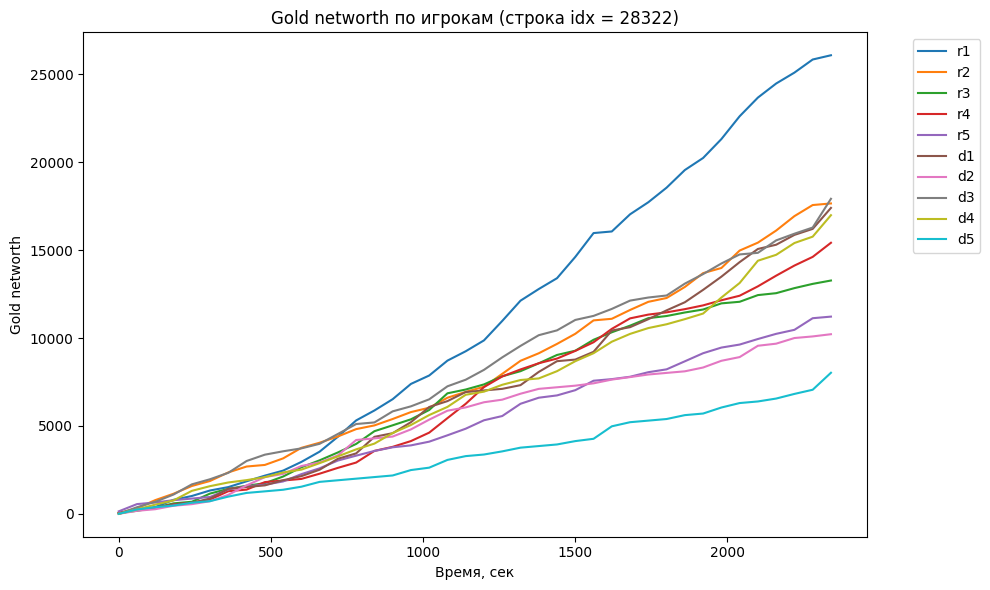

In [21]:
plot_match_timeseries(raw_features, idx=28322, metric="gold_t")

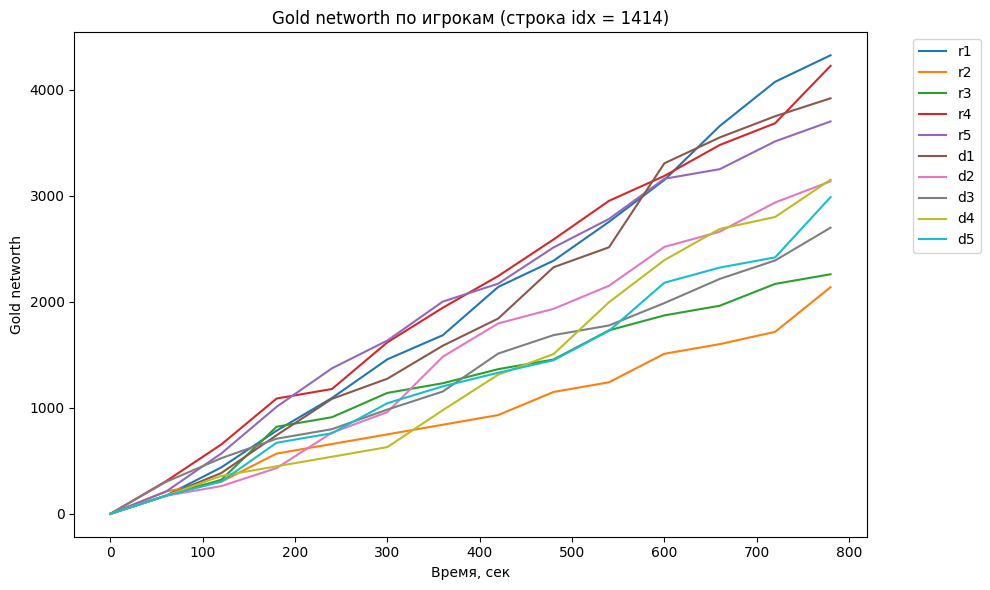

In [22]:
plot_match_timeseries(raw_features, idx=1414, metric="gold_t")

In [23]:
raw_features.iloc[0]

match_id_hash     a400b8f29dece5f4d266f49f1ae2e98a
game_time                                      155
game_mode                                       22
lobby_type                                       7
objectives_len                                   1
                                ...               
d1_gold_t                            [1, 331, 738]
d2_gold_t                            [1, 251, 561]
d3_gold_t                            [1, 251, 342]
d4_gold_t                            [1, 251, 342]
d5_gold_t                            [1, 425, 680]
Name: 0, Length: 269, dtype: object

In [24]:
X = df_feats.drop('match_id_hash', axis=1)
y = raw_targets["radiant_win"]

In [25]:
X

,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,r1_gold,r1_lh,r1_xp,r1_health,r1_max_health,r1_max_mana,r1_level,r1_x,r1_y,r1_stuns,r1_creeps_stacked,r1_camps_stacked,r1_rune_pickups,r1_firstblood_claimed,r1_teamfight_participation,r1_towers_killed,r1_roshans_killed,r1_obs_placed,r1_sen_placed,r2_hero_id,r2_kills,r2_deaths,r2_assists,r2_denies,r2_gold,r2_lh,r2_xp,r2_health,r2_max_health,r2_max_mana,r2_level,r2_x,r2_y,r2_stuns,r2_creeps_stacked,r2_camps_stacked,r2_rune_pickups,r2_firstblood_claimed,r2_teamfight_participation,r2_towers_killed,r2_roshans_killed,r2_obs_placed,r2_sen_placed,r3_hero_id,r3_kills,r3_deaths,r3_assists,r3_denies,r3_gold,r3_lh,r3_xp,r3_health,r3_max_health,r3_max_mana,r3_level,r3_x,r3_y,r3_stuns,r3_creeps_stacked,r3_camps_stacked,r3_rune_pickups,r3_firstblood_claimed,r3_teamfight_participation,r3_towers_killed,r3_roshans_killed,r3_obs_placed,r3_sen_placed,r4_hero_id,r4_kills,r4_deaths,r4_assists,r4_denies,r4_gold,r4_lh,r4_xp,r4_health,r4_max_health,r4_max_mana,r4_level,r4_x,r4_y,r4_stuns,r4_creeps_stacked,r4_camps_stacked,r4_rune_pickups,r4_firstblood_claimed,r4_teamfight_participation,r4_towers_killed,r4_roshans_killed,r4_obs_placed,r4_sen_placed,r5_hero_id,r5_kills,r5_deaths,r5_assists,r5_denies,r5_gold,r5_lh,r5_xp,r5_health,r5_max_health,r5_max_mana,r5_level,r5_x,r5_y,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed,d1_hero_id,d1_kills,d1_deaths,d1_assists,d1_denies,d1_gold,d1_lh,d1_xp,d1_health,d1_max_health,d1_max_mana,d1_level,d1_x,d1_y,d1_stuns,d1_creeps_stacked,d1_camps_stacked,d1_rune_pickups,d1_firstblood_claimed,d1_teamfight_participation,d1_towers_killed,d1_roshans_killed,d1_obs_placed,d1_sen_placed,d2_hero_id,d2_kills,d2_deaths,d2_assists,d2_denies,d2_gold,d2_lh,d2_xp,d2_health,d2_max_health,d2_max_mana,d2_level,d2_x,d2_y,d2_stuns,d2_creeps_stacked,d2_camps_stacked,d2_rune_pickups,d2_firstblood_claimed,d2_teamfight_participation,d2_towers_killed,d2_roshans_killed,d2_obs_placed,d2_sen_placed,d3_hero_id,d3_kills,d3_deaths,d3_assists,d3_denies,d3_gold,d3_lh,d3_xp,d3_health,d3_max_health,d3_max_mana,d3_level,d3_x,d3_y,d3_stuns,d3_creeps_stacked,d3_camps_stacked,d3_rune_pickups,d3_firstblood_claimed,d3_teamfight_participation,d3_towers_killed,d3_roshans_killed,d3_obs_placed,d3_sen_placed,d4_hero_id,d4_kills,d4_deaths,d4_assists,d4_denies,d4_gold,d4_lh,d4_xp,d4_health,d4_max_health,d4_max_mana,d4_level,d4_x,d4_y,d4_stuns,d4_creeps_stacked,d4_camps_stacked,d4_rune_pickups,d4_firstblood_claimed,d4_teamfight_participation,d4_towers_killed,d4_roshans_killed,d4_obs_placed,d4_sen_placed,d5_hero_id,d5_kills,d5_deaths,d5_assists,d5_denies,d5_gold,d5_lh,d5_xp,d5_health,d5_max_health,d5_max_mana,d5_level,d5_x,d5_y,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed,radiant_total_gold,dire_total_gold,radiant_gold_advantage,radiant_total_kills,dire_total_kills,radiant_kills_advantage,radiant_total_deaths,dire_total_deaths,radiant_deaths_advantage,radiant_total_level,dire_total_level,radiant_level_advantage,total_kills_deaths
0,155,22,7,1,11,11,0,0,0,0,543,7,533,358,600,350.93784,2,116,122,0.000000,0,0,1,0,0.000000,0,0,0,0,78,0,0,0,3,399,4,478,636,720,254.93774,2,124,126,0.000000,0,0,0,0,0.000000,0,0,0,0,14,0,1,0,0,304,0,130,700,700,242.93773,1,70,156,0.000000,0,0,1,0,0.000000,0,0,0,0,59,0,0,0,1,389,4,506,399,700,326.93780,2,170,86,0.000000,0,0,0,0,0.000000,0,0,0,0,77,0,0,0,0,402,10,344,422,800,314.93780,2,120,100,0.000000,0,0,0,0,0.000000,0,0,0,0,12,0,0,1,13,982,12,780,650,720,386.93787,3,82,170,0.000000,0,0,1,0,1.00000,0,0,0,0,21,0,0,0,6,788,9,706,640,640,422.93790,3,174,90,0.000000,0,0,2,0,0.00000,0,0,0,0,60,0,0,0,1,531,0,307,720,720,242.93773,2,180,84,0.299948,0,0,2,0,0.00000,0,0,0,0,84,1,0,0,0,796,0,421,760,7

In [26]:
y.head()

0    False
1     True
2     True
3     True
4    False
Name: radiant_win, dtype: bool

In [27]:
path = "DOTA 2//train_matches.jsonl"

with open(path, "r", encoding="utf-8") as f:
    for line in itertools.islice(f, 5):  # первые 5 строк
        print(line.strip())

{"game_time": 155, "match_id_hash": "a400b8f29dece5f4d266f49f1ae2e98a", "teamfights": [], "objectives": [{"time": 124.203, "type": "CHAT_MESSAGE_FIRSTBLOOD", "slot": 8, "key": 2, "player_slot": 131}], "chat": [{"player_slot": 0, "time": -13.63, "text": "???"}, {"player_slot": 0, "time": -10.964, "text": "? ???? ??????"}, {"player_slot": 0, "time": -7.965, "text": "???????? ????("}, {"player_slot": 4, "time": 43.756, "text": "???"}, {"player_slot": 2, "time": 44.422, "text": "??? ??????"}, {"player_slot": 4, "time": 45.289, "text": "*[*[*["}, {"player_slot": 2, "time": 46.622, "text": "????"}, {"player_slot": 4, "time": 47.355, "text": "??? ??????"}, {"player_slot": 4, "time": 48.688, "text": "????"}, {"player_slot": 2, "time": 52.021, "text": "???????? ??? ??????"}, {"player_slot": 4, "time": 73.349, "text": "????? ??? ?????"}], "game_mode": 22, "lobby_type": 7, "players": [{"player_slot": 0, "hero_id": 11, "hero_name": "npc_dota_hero_nevermore", "account_id_hash": "86bf86c548874247868

In [28]:
path = "DOTA 2//train_matches.jsonl"
count = 0

with open(path, "rb") as f:
    for block in iter(lambda: f.read(1024 * 1024), b""):  # читаем по 1 МБ
        count += block.count(b"\n")

print("Строк в файле:", count)


Строк в файле: 33723


In [29]:
path = "DOTA 2//test_matches.jsonl"
with open(path, "r", encoding="utf-8") as f:
    for line in itertools.islice(f, 5):  # первые 5 строк
        print(line.strip())

{"game_time": 1249, "match_id_hash": "4b6e4e511d399180776d0f23984466b2", "teamfights": [{"start": 335.581, "end": 369.61, "last_death": 354.114, "deaths": 3, "players": [{"deaths_pos": {}, "ability_uses": {"sandking_sand_storm": 1}, "item_uses": {}, "killed": {}, "deaths": 0, "buybacks": 0, "damage": 0, "healing": 0, "gold_delta": 157, "xp_delta": 166}, {"deaths_pos": {}, "ability_uses": {}, "item_uses": {}, "killed": {}, "deaths": 0, "buybacks": 0, "damage": 0, "healing": 0, "gold_delta": 84, "xp_delta": 111}, {"deaths_pos": {}, "ability_uses": {"furion_teleportation": 1}, "item_uses": {"magic_wand": 1, "phase_boots": 1}, "killed": {"npc_dota_hero_earthshaker": 71}, "deaths": 0, "buybacks": 0, "damage": 522, "healing": 0, "gold_delta": 170, "xp_delta": 23}, {"deaths_pos": {}, "ability_uses": {"chaos_knight_reality_rift": 1, "chaos_knight_chaos_bolt": 1}, "item_uses": {"power_treads": 3, "magic_wand": 1}, "killed": {}, "deaths": 0, "buybacks": 0, "damage": 307, "healing": 120, "gold_de

In [30]:
path = "DOTA 2//test_matches.jsonl"
count = 0

with open(path, "rb") as f:
    for block in iter(lambda: f.read(1024 * 1024), b""):  # читаем по 1 МБ
        count += block.count(b"\n")

print("Строк в файле:", count)


Строк в файле: 5952


In [31]:
src = "DOTA 2//train_matches.jsonl"
dst = "train_matches_sample.jsonl"

step = 1  # каждую сотую строку берём в семпл

with open(src, "r", encoding="utf-8") as fin, open(dst, "w", encoding="utf-8") as fout:
    for i, line in enumerate(fin, start=1):
        if not line.strip():
            continue
        if i % step == 0:
            fout.write(line)

print("Готово, семпл сохранён в", dst)

Готово, семпл сохранён в train_matches_sample.jsonl


# Предобработка

In [32]:
# import json

# jsonl_path = "DOTA 2/train_matches.jsonl"

# # set со всеми match_id_hash из файла
# jsonl_ids = set()

# with open(jsonl_path, "r", encoding="utf8") as f:
#     for line in f:
#         obj = json.loads(line)
#         jsonl_ids.add(obj["match_id_hash"])

# print("ID в JSONL:", len(jsonl_ids))


In [33]:
# feature_ids = set(raw_features["match_id_hash"])

# print("ID в таблице:", len(feature_ids))

# missing = jsonl_ids - feature_ids
# print("Отсутствуют:", len(missing))

# if missing:
#     print("Примеры отсутствующих:", list(missing)[:10])
# else:
#     print("Все match_id_hash присутствуют")


In [34]:
# import json

# train_path = "DOTA 2/train_matches.jsonl"
# test_path = "DOTA 2/test_matches.jsonl"

# def load_ids(path):
#     ids = set()
#     with open(path, "r", encoding="utf8") as f:
#         for line in f:
#             obj = json.loads(line)
#             ids.add(obj["match_id_hash"])
#     return ids

# # Загружаем id из обоих файлов
# train_ids = load_ids(train_path)
# test_ids = load_ids(test_path)

# # Объединяем множества
# jsonl_ids = train_ids.union(test_ids)

# print("ID в train:", len(train_ids))
# print("ID в test:", len(test_ids))
# print("Всего уникальных ID:", len(jsonl_ids))

# # ID из твоей таблицы признаков
# feature_ids = set(raw_features["match_id_hash"])

# print("ID в таблице:", len(feature_ids))

# # Проверка отсутствующих
# missing = jsonl_ids - feature_ids
# print("Отсутствуют:", len(missing))

# if missing:
#     print("Примеры отсутствующих:", list(missing)[:10])
# else:
#     print("Все match_id_hash присутствуют в таблице признаков")


In [35]:
# import json

# train_path = "DOTA 2/train_matches.jsonl"
# test_path = "DOTA 2/test_matches.jsonl"

# def load_ids(path):
#     ids = set()
#     with open(path, "r", encoding="utf8") as f:
#         for line in f:
#             obj = json.loads(line)
#             ids.add(obj["match_id_hash"])
#     return ids

# # Загружаем id из обоих файлов
# train_ids = load_ids(train_path)
# test_ids = load_ids(test_path)

# # Объединяем множества
# jsonl_ids = train_ids.union(test_ids)

# print("ID в train:", len(train_ids))
# print("ID в test:", len(test_ids))
# print("Всего уникальных ID:", len(jsonl_ids))

# # ID из твоей таблицы признаков
# feature_ids = set(test_features["match_id_hash"])

# print("ID в таблице:", len(feature_ids))

# # Проверка отсутствующих
# missing = jsonl_ids - feature_ids
# print("Отсутствуют:", len(missing))

# if missing:
#     print("Примеры отсутствующих:", list(missing)[:10])
# else:
#     print("Все match_id_hash присутствуют в таблице признаков")


In [36]:
# df = pd.read_json("train_matches_sample.jsonl", lines=True)
# df.head()

In [37]:
# df['players'][1]

# Моделирование

## Catboost

In [38]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=7,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=RANDOM_STATE,
    verbose=100)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,      
    random_state=RANDOM_STATE,    
    stratify=y,
    shuffle=True         
)

model.fit(X_train, y_train)#, eval_set=(X_test, y_test), verbose=100)

0:	total: 155ms	remaining: 2m 35s
100:	total: 1.39s	remaining: 12.4s
200:	total: 2.59s	remaining: 10.3s
300:	total: 3.79s	remaining: 8.81s
400:	total: 5.01s	remaining: 7.49s
500:	total: 6.21s	remaining: 6.19s
600:	total: 7.4s	remaining: 4.91s
700:	total: 8.6s	remaining: 3.67s
800:	total: 9.79s	remaining: 2.43s
900:	total: 11s	remaining: 1.21s
999:	total: 12.1s	remaining: 0us


# Оценка

In [39]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.7269
ROC AUC: 0.8163


In [40]:
y_pred

array([ True,  True, False, ..., False,  True,  True])

In [41]:
# model = CatBoostClassifier(
#     iterations=1000,
#     learning_rate=0.1,
#     depth=7,
#     loss_function='Logloss',
#     eval_metric='AUC',
#     random_state=RANDOM_STATE,
#     verbose=100)


# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.25,      
#     random_state=RANDOM_STATE,    
#     stratify=y,
#     shuffle=True         
# )

# model.fit(X_train, y_train)#, eval_set=(X_test, y_test), verbose=100)

# y_pred = model.predict(X_test)
# accuracy = accuracy_score(y_test, y_pred)
# roc_auc = roc_auc_score(y_test, y_pred)

# print(f"Accuracy: {accuracy:.4f}")
# print(f"ROC AUC: {roc_auc:.4f}")


# Выводы